# Chapter 01 — Descriptive Statistics
### Dataset: Titanic | Subject 01 of 09: Statistics & Probability

---

**What this notebook is about**

Before building any model, you need to *understand* your data. Descriptive statistics is that first conversation — it tells you the shape, spread, and relationships in your data before you touch a single algorithm.

This notebook covers four core tasks on the Titanic dataset:

| Task | Concept Practised |
|------|-------------------|
| Mean vs Median Age | Central tendency, skewness, outlier effect |
| Fare Distribution | Right skew, reporting choice, segmentation |
| Survival Rate by Class | Conditional analysis, predictive features |
| Correlation Matrix | Feature relationships, causation vs correlation |

**The goal is not to compute numbers — it is to interpret them and connect them to real decisions.**

---


## Setup — Imports & Data Loading

In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load the Titanic dataset directly from seaborn
df = sns.load_dataset('titanic')

print(f"Dataset shape: {df.shape[0]} passengers, {df.shape[1]} columns")
print()
print("Column reference:")
column_descriptions = {
    'survived' : '0 = died, 1 = survived  ← target variable',
    'pclass'   : 'Passenger class: 1 = First, 2 = Second, 3 = Third',
    'sex'      : 'male / female',
    'age'      : 'Age in years (has missing values)',
    'sibsp'    : 'Number of siblings or spouses aboard',
    'parch'    : 'Number of parents or children aboard',
    'fare'     : 'Ticket price paid',
    'embarked' : 'Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton',
    'class'    : 'Same as pclass but as text',
    'who'      : 'man / woman / child',
    'adult_male': 'True if adult male',
    'deck'     : 'Cabin deck (many missing values)',
    'embark_town': 'Full city name of embarkation port',
    'alive'    : 'yes / no — same as survived',
    'alone'    : 'True if travelling solo (sibsp=0 and parch=0)',
}
for col, desc in column_descriptions.items():
    print(f"  {col:<14} {desc}")


Dataset shape: 891 passengers, 15 columns

Column reference:
  survived       0 = died, 1 = survived  ← target variable
  pclass         Passenger class: 1 = First, 2 = Second, 3 = Third
  sex            male / female
  age            Age in years (has missing values)
  sibsp          Number of siblings or spouses aboard
  parch          Number of parents or children aboard
  fare           Ticket price paid
  embarked       Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton
  class          Same as pclass but as text
  who            man / woman / child
  adult_male     True if adult male
  deck           Cabin deck (many missing values)
  embark_town    Full city name of embarkation port
  alive          yes / no — same as survived
  alone          True if travelling solo (sibsp=0 and parch=0)


In [20]:
# Preview the first five rows
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Mean vs Median Age

### Why both?

Mean and median both describe the centre of a distribution, but they behave differently when outliers or skew are present.

- **Mean** uses every data point. One extreme value shifts it.
- **Median** finds the middle position. Extreme values do not move it.

**Rule of thumb:** If mean and median are close → distribution is roughly symmetric → mean is safe to report.
If mean >> median → distribution is right-skewed → median better represents the typical observation.

> **Interview insight:** Reporting the *gap* between mean and median is itself a finding. A large gap signals skewness, which has downstream consequences for modelling (violated regression assumptions, need for log transformation, etc.).


In [21]:
mean_age   = round(df['age'].mean(), 2)
median_age = df['age'].median()
diff_age   = round(mean_age - median_age, 2)

print(f"Mean age   : {mean_age}")
print(f"Median age : {median_age}")
print(f"Difference : {diff_age}")
print()

if abs(diff_age) < 3:
    print("Interpretation: Mean and median are close → roughly symmetric distribution.")
    print("Mean is appropriate to report here.")
else:
    print("Interpretation: Notable gap → skewed distribution.")
    print("Prefer median for reporting to avoid overstating / understating the typical age.")


Mean age   : 29.7
Median age : 28.0
Difference : 1.7

Interpretation: Mean and median are close → roughly symmetric distribution.
Mean is appropriate to report here.


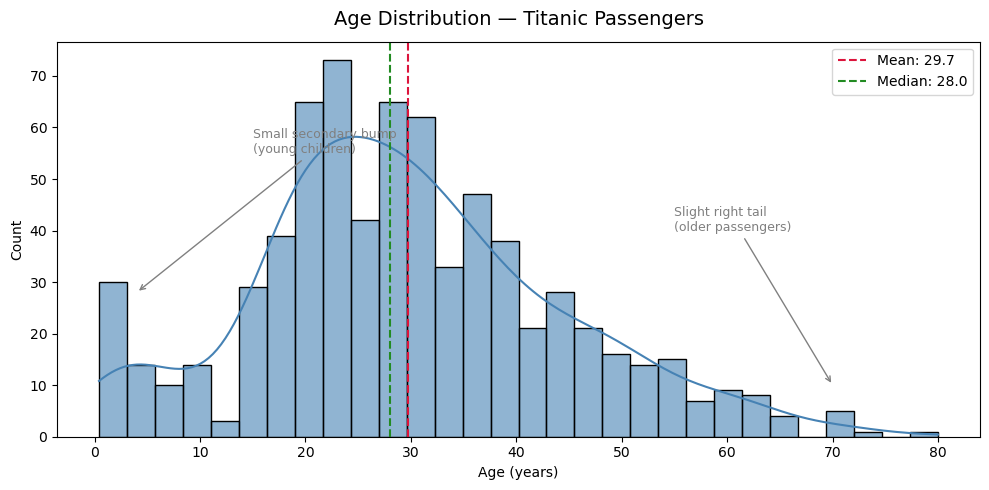

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=ax, color='steelblue', alpha=0.6)

ax.axvline(mean_age,   color='crimson',     linestyle='--', linewidth=1.5, label=f'Mean: {mean_age}')
ax.axvline(median_age, color='forestgreen', linestyle='--', linewidth=1.5, label=f'Median: {median_age}')

ax.set_title('Age Distribution — Titanic Passengers', fontsize=14, pad=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()

# Annotation
ax.annotate(
    'Small secondary bump\n(young children)',
    xy=(4, 28), xytext=(15, 55),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
ax.annotate(
    'Slight right tail\n(older passengers)',
    xy=(70, 10), xytext=(55, 40),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()


### Findings — Age

- Distribution is **slightly right-skewed** with a small secondary bump of young children on the left.
- The tail stretches right toward older passengers (likely wealthier first-class travellers).
- Mean (29.7) and median (28.0) differ by only 1.7 — a small gap relative to the 0–80 range.
- **Reporting choice:** Either is defensible, but median is slightly more robust. Always plot before deciding.

> **What the children's bump tells us:** The Titanic carried families with young children, particularly in third class. This bimodal-ish feature is worth noting — if we were building an age-based model, we might engineer a separate binary feature `is_child` rather than treating age as purely continuous.

> **Note on missing values:** `df['age'].dropna()` was used in the plot. Age has 177 missing values (19.9% of passengers). For modelling, this requires an imputation strategy — a topic covered in Chapter 4.


---
## Task 2 — Fare Distribution

### What to expect

The Titanic carried passengers across three classes with dramatically different ticket prices. Most passengers were third class (491 of 891). This immediately suggests the fare distribution will be **right-skewed** — a large cluster of low fares on the left, a long tail of expensive first-class tickets on the right.

**Prediction before computing:** Mean fare > Median fare.


In [23]:
mean_fare   = round(df['fare'].mean(), 2)
median_fare = round(df['fare'].median(), 2)
diff_fare   = round(mean_fare - median_fare, 2)

print(f"Mean fare   : ${mean_fare}")
print(f"Median fare : ${median_fare}")
print(f"Difference  : ${diff_fare}")
print()
print(f"The mean is {round(mean_fare / median_fare, 1)}x the median — classic right skew.")
print("A handful of expensive first-class tickets are pulling the mean far above the typical fare.")


Mean fare   : $32.2
Median fare : $14.45
Difference  : $17.75

The mean is 2.2x the median — classic right skew.
A handful of expensive first-class tickets are pulling the mean far above the typical fare.


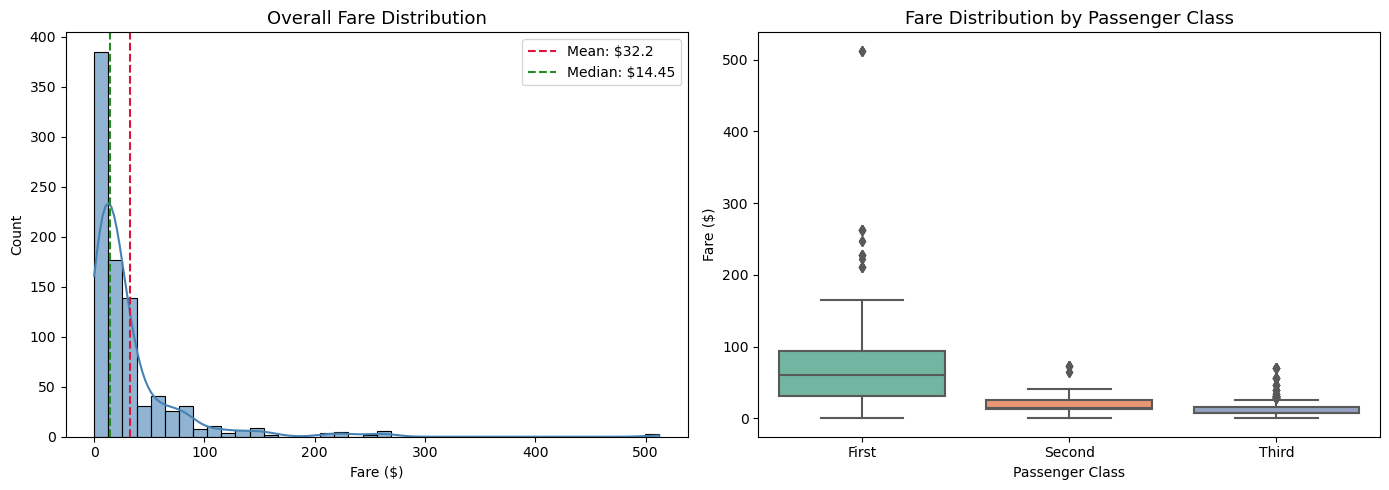

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall fare distribution
sns.histplot(df['fare'].dropna(), bins=40, kde=True, ax=axes[0], color='steelblue', alpha=0.6)
axes[0].axvline(mean_fare,   color='crimson',     linestyle='--', linewidth=1.5, label=f'Mean: ${mean_fare}')
axes[0].axvline(median_fare, color='forestgreen', linestyle='--', linewidth=1.5, label=f'Median: ${median_fare}')
axes[0].set_title('Overall Fare Distribution', fontsize=13)
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: fare by class — boxplot
sns.boxplot(x='pclass', y='fare', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Fare Distribution by Passenger Class', fontsize=13)
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Fare ($)')
axes[1].set_xticklabels(['First', 'Second', 'Third'])

plt.tight_layout()
plt.show()


In [25]:
# Passenger count and median fare per class — the numbers behind the boxplot
class_summary = df.groupby('pclass').agg(
    passenger_count=('survived', 'count'),
    median_fare=('fare', 'median'),
    mean_fare=('fare', 'mean'),
    max_fare=('fare', 'max')
).round(2)

class_summary.index = ['First', 'Second', 'Third']
print("Fare summary by passenger class:")
print(class_summary.to_string())


Fare summary by passenger class:
        passenger_count  median_fare  mean_fare  max_fare
First               216        60.29      84.15    512.33
Second              184        14.25      20.66     73.50
Third               491         8.05      13.68     69.55


### Findings — Fare

- Fare distribution is **heavily right-skewed**. Mean ($32.20) is more than double the median ($14.45).
- The median is the correct measure to report for "typical passenger fare."
- Most passengers were **third class (491)**, paying a median of ~$8.
- First class passengers paid up to $512 — roughly **7.5× the median first-class fare** of $60.
- The boxplot clearly shows first-class fares had enormous variance (large IQR box), while third-class fares were tightly packed near zero (small IQR box).

> **Segmentation insight:** Reporting a single fare average for all passengers is misleading. The data is bimodal in structure — there are really three distinct pricing tiers. Always segment before summarising.

> **The outlier at $512:** This is not an error. A small number of first-class passengers paid premium fares, likely for private cabins and exclusive amenities. These outliers are real signal, not noise.


---
## Task 3 — Survival Rate by Passenger Class

### The business question

Does passenger class predict survival? This is a conditional analysis question — we're asking: *given* that a passenger was in Class X, what was their probability of surviving?

This is also a feature relevance question. In ML terms: is `pclass` a useful predictor for the `survived` target variable?

**Note:** Survival rate is a percentage, not a raw count. Class 3 having more passengers does not mean they had higher survival — it means more people were at risk.


In [26]:
survival_by_class = df.groupby('pclass')['survived'].mean().round(4)
passenger_counts  = df.groupby('pclass')['survived'].count()

print("Survival rate by passenger class:")
print()
for cls in [1, 2, 3]:
    rate  = survival_by_class[cls]
    count = passenger_counts[cls]
    survived_n = round(rate * count)
    print(f"  Class {cls}: {rate*100:.1f}% survived  ({survived_n} of {count} passengers)")


Survival rate by passenger class:

  Class 1: 63.0% survived  (136 of 216 passengers)
  Class 2: 47.3% survived  (87 of 184 passengers)
  Class 3: 24.2% survived  (119 of 491 passengers)


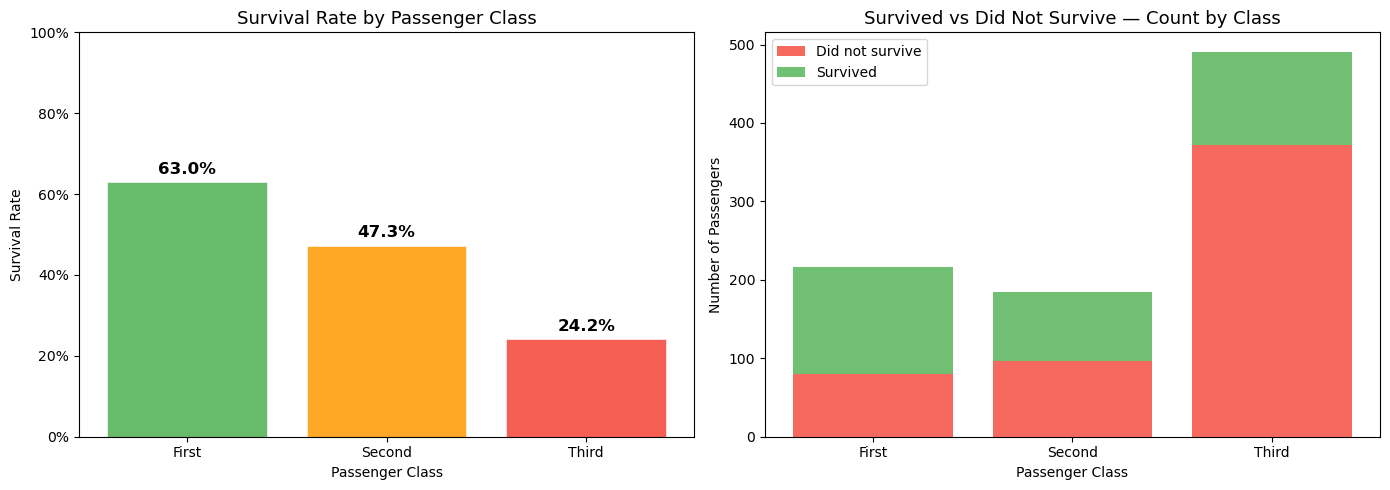

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: survival rate bar chart
colors = ['#4CAF50', '#FF9800', '#F44336']
bars = axes[0].bar(['First', 'Second', 'Third'],
                   survival_by_class.values,
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, survival_by_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.02,
                 f'{val*100:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)

axes[0].set_title('Survival Rate by Passenger Class', fontsize=13)
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1.0)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# Right: stacked bar — survived vs died count per class
survived_counts = df[df['survived']==1].groupby('pclass').size()
died_counts     = df[df['survived']==0].groupby('pclass').size()
class_labels    = ['First', 'Second', 'Third']

axes[1].bar(class_labels, died_counts.values,     label='Did not survive', color='#F44336', alpha=0.8)
axes[1].bar(class_labels, survived_counts.values, bottom=died_counts.values, label='Survived', color='#4CAF50', alpha=0.8)

axes[1].set_title('Survived vs Did Not Survive — Count by Class', fontsize=13)
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Number of Passengers')
axes[1].legend()

plt.tight_layout()
plt.show()


### Findings — Survival Rate by Class

| Class | Survival Rate | Interpretation |
|-------|--------------|----------------|
| First  | 63.0% | Majority survived |
| Second | 47.0% | Near coin-flip |
| Third  | 24.0% | Less than 1 in 4 survived |

- Survival rate drops dramatically from First to Third class — a **2.6× gap** between the highest and lowest.
- `pclass` is a **strong predictor of survival**, making it a high-value feature for any classification model on this dataset.

**Why did class predict survival?**

Three compounding factors:
1. **Physical location:** Third-class cabins were on lower decks, farther from lifeboats.
2. **Evacuation priority:** Historical accounts document that first-class passengers received earlier notification and assistance.
3. **Resources:** Wealthier passengers may have had greater physical and social capital to navigate the chaos.

> **Correlation vs causation note:** Class *predicts* survival in this data. But wealth was also correlated with age, gender ratio, and social connections — all potential confounders. The relationship is real and strong, but the causal mechanism is complex. This is exactly why feature correlation alone is never a full explanation.

> **Interview framing:** "I would describe `pclass` as a strong predictive feature for survival (63% vs 24% survival rate across classes), but I would be careful about causal language. The association is likely mediated by deck location, evacuation access, and social factors — all of which are unmeasured confounders in this dataset."


---
## Task 4 — Correlation Matrix of Numeric Columns

### What the correlation matrix tells you

A correlation matrix shows the **Pearson correlation coefficient** between every pair of numeric columns simultaneously.

- Values range from **-1 to +1**
- **+1:** Perfect positive linear relationship — as one increases, the other increases proportionally
- **-1:** Perfect negative linear relationship — as one increases, the other decreases proportionally
- **0:** No linear relationship

**Reading the matrix:**
- Diagonal is always 1.0 — every column is perfectly correlated with itself
- Dark red = strong positive correlation
- Dark blue = strong negative correlation
- Light / white = weak or no correlation

**What to look for:**
1. Which features correlate most strongly with `survived`? → These are your most predictive features
2. Which features correlate strongly with *each other*? → These are multicollinearity candidates (covered in depth in Chapter 4)


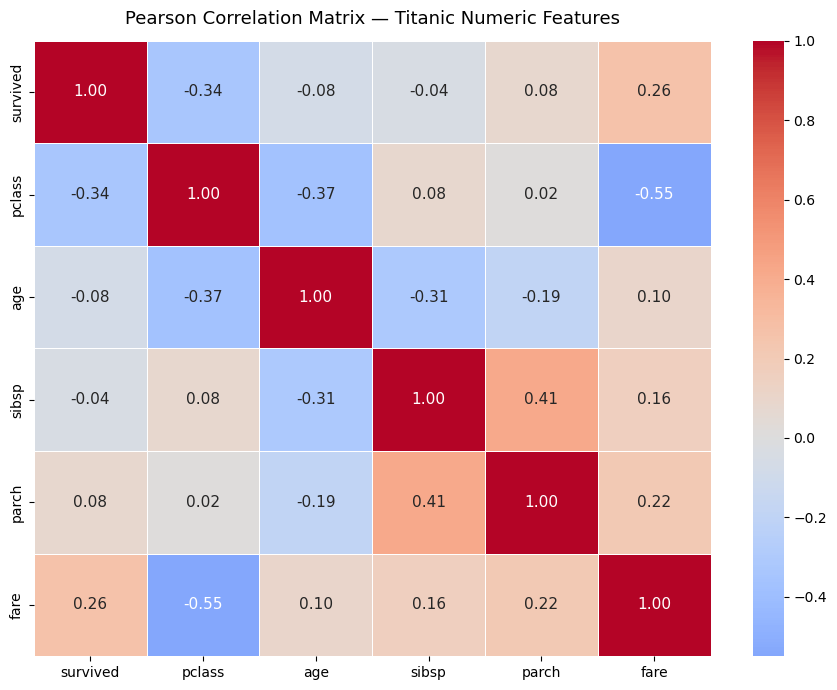

In [28]:
numeric_cols       = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]
correlation_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Pearson Correlation Matrix — Titanic Numeric Features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


In [29]:
# Summarise the survived row — most relevant for feature selection
survived_corr = correlation_matrix['survived'].drop('survived').sort_values(key=abs, ascending=False)

print("Correlation with survival (sorted by absolute strength):")
print()
for feature, corr in survived_corr.items():
    direction = 'positive' if corr > 0 else 'negative'
    strength  = 'strong' if abs(corr) > 0.3 else 'moderate' if abs(corr) > 0.15 else 'weak'
    print(f"  {feature:<10} r = {corr:+.2f}   {strength} {direction}")


Correlation with survival (sorted by absolute strength):

  pclass     r = -0.34   strong negative
  fare       r = +0.26   moderate positive
  parch      r = +0.08   weak positive
  age        r = -0.08   weak negative
  sibsp      r = -0.04   weak negative


### Findings — Correlation Matrix

**Features correlated with survival:**

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| `pclass` | -0.34 | Higher class number (lower class) → lower survival |
| `fare`   | +0.26 | Higher fare → higher survival |
| `parch`  | +0.08 | Very weak — travelling with children/parents had minimal effect |
| `age`    | -0.08 | Very weak — age barely predicts survival on its own |
| `sibsp`  | -0.04 | Negligible |

**Key feature-to-feature correlations (multicollinearity watch):**

- `pclass` and `fare`: **-0.55** — strong negative relationship. Higher class number = lower fare. These two features are partially redundant — they carry overlapping information about socioeconomic status. In a regression model, including both would cause multicollinearity. See Chapter 4.
- `sibsp` and `parch`: **+0.41** — moderate positive. Passengers with siblings/spouses were also likely to have parents/children aboard. Both measure "family size" — another potential redundancy.

> **Correlation vs causation reminder:** `pclass` correlating with `survived` at -0.34 does not mean class *caused* survival differences. As established in Task 3, deck location, evacuation access, and social factors are confounders. High correlation is a useful signal for model building, but never a complete causal explanation.

> **Senior-level framing:** "Before including both `pclass` and `fare` in a regression model, I would check their VIF scores. Given the -0.55 correlation between them, one likely adds limited independent information once the other is included. I would either drop one, combine them into a socioeconomic index, or use regularisation (Ridge) to let the model handle the redundancy. This is covered in Chapter 4."


---
## Chapter Summary — Key Takeaways

### Central Tendency
- Always compute both mean and median. The **gap between them** is the finding.
- Large gap → skewed distribution → report median as the typical value.
- Small gap → roughly symmetric → mean is appropriate.

### Spread
- **Std dev** uses every data point. Sensitive to outliers. Use for symmetric data and modelling.
- **IQR** uses only the middle 50%. Robust to outliers. Use for skewed data and reporting.
- Report them as a pair: mean + std dev *or* median + IQR. Never mix.

### Shape
- **Skewness:** Determined by where the *tail* is, not where the hump is. Right tail = right skew = mean > median.
- **Kurtosis:** How fat the tails are. High kurtosis = extreme events more common than normal distribution predicts. Critical for risk and fraud models.
- Always plot before reporting. Numbers alone can miss bimodal distributions.

### Relationships
- **Pearson correlation:** Measures linear relationships. Sensitive to outliers.
- **Spearman correlation:** Rank-based. Works for monotonic (curved but consistent) relationships and is robust to outliers.
- **Correlation ≠ causation.** Always ask: is there a confounding variable? Can we run an experiment to establish causation?

### Interview Must-Knows
| Question | Senior Answer |
|----------|---------------|
| When to report median? | When distribution is skewed or has outliers. Report both and explain the gap. |
| Outliers affect std dev vs IQR how? | Std dev inflates (squaring amplifies extremes). IQR is unaffected (only uses middle 50%). |
| Correlation of 0.9 between two features? | Multicollinearity risk. Check VIF. Consider dropping one or using Ridge regularisation. |
| Correlation ≠ causation example? | Ice cream sales and drowning rates — both driven by summer heat (confounder). |

---
*Part of the DS Interview Masterbook — Chapter 01 of 09: Statistics & Probability*
